# **Filtrage utilisant des autoencodeurs "Denoising Autoencoders"**


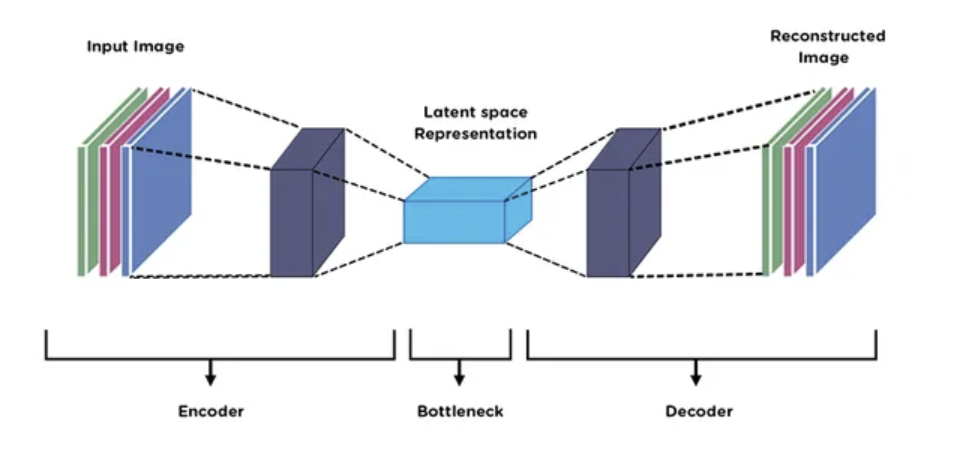

# Introduction

Auto Encoders are by far one of the most powerful deep learning models that can be used for a variety of purposes. Over time, many kinds of Auto Encoders have come out

1. Standard AutoEncoders - Can be used to compress and decompress information (including images)
2. Variational AutoEncoders - Can be used to generate images like GANs.
3. Denoising AutoEncoders - Can be used to remove noise from images, making them clearer. (They have a much wider use case such as increasing resolution of images as well).



# Why Denoising AutoEncoders

The obvious use case of denoising autoencoders is to, well, clean noisy images.

However, the same model (with different training and testing data) can also be used to increase the resolution of blurry images. Then even photos taken by an amateur on a low resolution camera can be turned into stunning hig res images!


We will use the MNIST dataset. The MNIST dataset is a large collection of  handwritten digit images (0–9), each in 28×28 grayscale format.
It is widely used for training and testing image classification algorithms, and can be accessed via libraries like TensorFlow and PyTorch.




# How Do AutoEncoders Work
1. Encoder

The encoder takes the input image (or data) and compresses it into a lower-dimensional representation. This compressed version is called the latent space representation or code.

**Purpose:** Capture the most important features of the input data.

 2. Bottleneck (Latent Space Representation)

This is the compressed version of the original input—essentially the "essence" of the data in fewer dimensions.

The bottleneck forces the model to learn compact and meaningful features, helping in things like compression or noise removal.

 3. Decoder

The decoder takes the latent representation and reconstructs the original input as closely as possible.

It's trained to output something as close as possible to the input image.




Loss Function: The loss function essentially wants the encoder and decoder to cooperate such that the data reconstructed at the end, is as close as possible to the original input image. This way, we don't need any labels, because the training data is the label.

And that's it!


These autoencoders can be used for denoising images (we will using convolutional layers instead since they work better on image data).

# Implementation in Keras

In [1]:
## sur votre machine perso
##-------- create your env with these followings lines --------: 
#python3 -m venv my_env_name 
#source my_env_name/bin/activate   


##-----sur les machines des salles de TP, appliquez la ligne suivante pour activer python-ensimag --------
#source /opt/python-ensimag/bin/activate


##Importing necessary libraries, install them if they are not
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import MNIST

np.random.seed(1337)
torch.manual_seed(1337)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch Version:", torch.__version__)
print("Device:", device)

/opt/python-ensimag/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


PyTorch Version: 2.3.0+cu121
Device: cuda


In [2]:
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Current GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU count: 1
Current GPU: Quadro P620


As mentioned before, the training data is the target data as well, so when we load in the mnist, we will ignore the labels.

In [3]:
# Loading MNIST data - we don't want the labels
train_dataset_raw = MNIST(root="./data", train=True, download=True)
test_dataset_raw = MNIST(root="./data", train=False, download=True)

x_train = train_dataset_raw.data.numpy()
x_test = test_dataset_raw.data.numpy()

Now, we want the model to filter noise, so the input images will be noisy. We will have to create these from the training data, and we will do that by adding random values to the data.

Q1: Normalizing the data (x_train and x_test) between 0 and 1. Explain why this step is crucial for the ML pipeline.

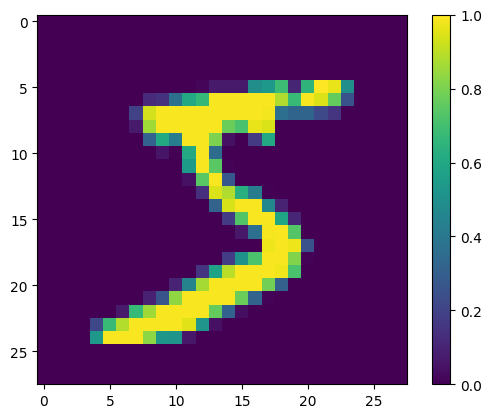

In [4]:
# Normalizing the data between 0 and 1
x_train = x_train / 255
x_test = x_test / 255
plt.imshow(x_train[0,:,:])
plt.colorbar()
plt.show()

Q2:  Generate corrupted MNIST images by adding noise with normal distribution centered at 0.5 and std=0.5

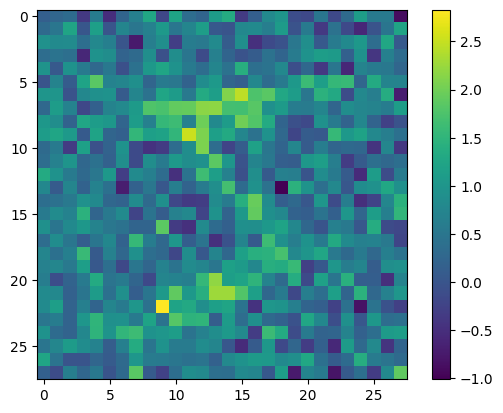

In [5]:
# your code
x_train_noisy = x_train + np.random.normal(loc=0.5, scale = 0.5, size = x_train.shape)
x_test_noisy = x_test + np.random.normal(loc=0.5, scale = 0.5, size = x_test.shape)
plt.imshow(x_train_noisy[0,:,:])
plt.colorbar()
plt.show()

Q3: Even after noise, we don't want values below 0 or more than 1. Use torch.clamp function to do so.

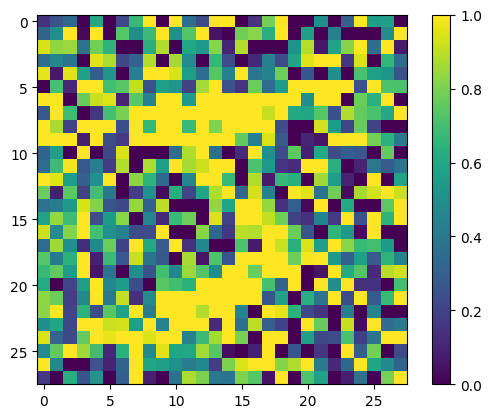

In [6]:
# Even after noise, we don't want values below 0 or more than 1
x_train_noisy =  np.clip(x_train_noisy, 0, 1)
x_test_noisy = np.clip(x_test_noisy, 0, 1)
plt.imshow(x_train_noisy[0,:,:])
plt.colorbar()
plt.show()

Now let's move on to build the encoder and decoder.

The encoder will have 3 convolutional layers, with increasing number of filters but decreasing image size (like a standard CNN). We will then flatten it and feed it into a Dense layer, which will finally compress the information into a smaller number of neurons.

In [87]:
#Defining how small the middle compression layer should be
latent_dim = 16

# Encoder

### Q4: Building the Encoder

In this exercise, we will build the encoder model in **PyTorch** following these steps:

1. **Create the input tensor** for grayscale images of size **28 × 28**.  
   In PyTorch, the input format is **(batch_size, channels, height, width)**.  
   Therefore, a batch of input images must have shape **(batch_size, 1, 28, 28)**.  
   This choice is justified because the images are grayscale, so they contain only **one channel**.

2. **First Convolutional Layer** using `torch.nn.Conv2d` with **16 output channels**.  
   The kernel size is **3 × 3**, the stride is **1**, and the padding is **1** so that the spatial dimensions remain unchanged.  
   The activation function used is **ReLU**, implemented with `torch.nn.ReLU`.

3. **Second Convolutional Layer** using `torch.nn.Conv2d` with **32 output channels** and a **3 × 3** kernel.  
   The stride is set to **2**, which reduces the spatial dimensions of the feature maps by half.  
   The padding remains **1**, and the activation function is again **ReLU**.

4. **Third Convolutional Layer** using `torch.nn.Conv2d` with **64 output channels** and a **3 × 3** kernel.  
   The stride is again set to **2**, which continues the downsampling process.  
   The padding is **1**, and **ReLU** is used as the activation function.

5. **Store the shape** of the output after the convolutional layers in a variable called `enc_shape`.  
   In PyTorch, this can be done using `x.shape` inside the `forward()` method.  
   This shape will be useful later in the decoder to reconstruct the feature maps before applying transpose convolutions.

6. **Flatten the output** of the last convolutional layer using `torch.nn.Flatten`.  
   This transforms the multi-dimensional feature map into a one-dimensional vector.

7. **Latent Space Layer:** add a fully connected layer using `torch.nn.Linear` with a number of output units equal to `latent_dim`.  
   This layer corresponds to the **bottleneck** of the autoencoder, where the input image is compressed into a lower-dimensional representation containing its most important features.

8. **Encoder Model:** in PyTorch, the encoder is implemented as a class inheriting from `torch.nn.Module`.  
   The layers are defined in the `__init__()` method, and the data flow is specified in the `forward()` method.  
   The encoder outputs the compressed representation produced by the latent layer.

In [35]:
# SOLUTION
tensor_x_train = torch.from_numpy(x_train).float().unsqueeze(1).to(device)
tensor_x_test = torch.from_numpy(x_test).float().unsqueeze(1).to(device)

class Encoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels = 1, out_channels = 16, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, stride = 2, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU()
        )
       
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64*7*7,latent_dim)

        self.enc_shape = None

    def forward(self, x):
        x = self.features(x)
        self.enc_shape = x.shape
        x = self.flatten(x)
        x = self.fc(x)
        return x


encoder = Encoder(latent_dim=latent_dim).to(device)

Q5: Display  a summary of your encoder model.

In [36]:
print(encoder)

# display the shape of input: (28, 28)
with torch.no_grad():
    dummy = torch.randn(1, 1, 28, 28).to(device)
    print("Encoder output shape:", encoder(dummy).shape)

Encoder(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=3136, out_features=16, bias=True)
)
Encoder output shape: torch.Size([1, 16])


# Decoder

### Q5: Building the Decoder

In this exercise, we will build the decoder model in **PyTorch** following these steps:

1. **Create the decoder input** as a latent vector of size `latent_dim`.  
   This vector is the compressed representation produced by the encoder.  
   In PyTorch, it will have shape **(batch_size, latent_dim)**.

2. **First Fully Connected Layer** using `torch.nn.Linear`.  
   This layer transforms the latent vector into a number of units equal to the total number of elements required to reconstruct the feature map before flattening.  
   For example, if the stored encoder shape is `(64, 7, 7)`, then the output size of this layer must be **64 × 7 × 7**.

3. **Reshape the output** of the fully connected layer into a 3D feature map.  
   In PyTorch, this can be done using `x.view(batch_size, 64, 7, 7)` or `x.reshape(...)`.  
   This restores the spatial structure needed before applying transposed convolutions.

4. **First Transposed Convolutional Layer** using `torch.nn.ConvTranspose2d` with **32 output channels**.  
   The kernel size is **3 × 3**, the stride is **2**, the padding is **1**, and an `output_padding=1` is usually added so that the spatial dimensions are correctly upsampled.  
   The activation function used is **ReLU**, implemented with `torch.nn.ReLU`.

5. **Second Transposed Convolutional Layer** using `torch.nn.ConvTranspose2d` with **16 output channels**.  
   The kernel size remains **3 × 3**, the stride is **2**, the padding is **1**, and `output_padding=1` is used again.  
   This layer continues the upsampling process.  
   The activation function is again **ReLU**.

6. **Final Transposed Convolutional Layer** using `torch.nn.ConvTranspose2d` with **1 output channel**, because the reconstructed image is grayscale.  
   The kernel size is **3 × 3**, the stride is **1**, and the padding is **1** so that the final output has the same spatial dimensions as the original image, namely **28 × 28**.

7. **Output Activation Function:** apply a **Sigmoid** activation using `torch.nn.Sigmoid` at the output of the decoder.  
   This constrains the reconstructed pixel values to the range **[0, 1]**, which is appropriate when the input images are normalized.

8. **Decoder Model:** in PyTorch, the decoder is implemented as a class inheriting from `torch.nn.Module`.  
   The layers are defined in the `__init__()` method, and the reconstruction process is specified in the `forward()` method.  
   The decoder takes the latent vector as input and outputs the reconstructed image.

In [37]:
# SOLUTION 
# #TODO

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(16, 64*7*7)
        self.features = nn.Sequential(
            nn.ConvTranspose2d(in_channels = 64, out_channels = 32, kernel_size = 3, stride = 2, padding = 1, output_padding = 1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels = 32, out_channels = 16, kernel_size = 3, stride = 2, padding = 1, output_padding = 1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels = 16, out_channels = 1, kernel_size = 3, stride = 1, padding = 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 7, 7)
        x = self.features(x)
        return x
            
    

decoder = Decoder(latent_dim=latent_dim).to(device)
print(decoder)

with torch.no_grad():
    dummy = torch.randn(1, latent_dim).to(device)
    print("Decoder output shape:", decoder(dummy).shape)

Decoder(
  (fc): Linear(in_features=16, out_features=3136, bias=True)
  (features): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)
Decoder output shape: torch.Size([1, 1, 28, 28])


# Final AutoEncoder

7: Now we will combine the two models to form the final Denoising AutoEncoder in PyTorch.

In [38]:
# Building Full Denoising AutoEncoder
# Here you should connect you encoder and your decoder via the latent space
class DenoisingAutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        x = self.encoder.forward(x)
        x = self.decoder.forward(x)
        return x

denoiser = DenoisingAutoEncoder(latent_dim=latent_dim).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(denoiser.parameters(), lr=1e-3)

print(denoiser)

DenoisingAutoEncoder(
  (encoder): Encoder(
    (features): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
    )
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc): Linear(in_features=3136, out_features=16, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=16, out_features=3136, bias=True)
    (features): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): Sigmoid()
    )
  )
)


Q8: Train the model for 30 epochs, although 20 - 25 should do good enough (you decide depending on your PC/GPU).
Since we don't want the model to overfit to noise in every update and make slow progress, we will use a batch size of 500.

In PyTorch, this means:
1. Create DataLoaders for the noisy inputs and clean targets using `torch.utils.data.DataLoader`
2. Iterate through mini-batches
3. Compute the loss
4. Backpropagate with `loss.backward()`
5. Update weights with `optimizer.step()`
6. Evaluate on the Test set
7. Display the training and validation loss for every epooch

In [39]:
# Training Final AutoEncoder
batch_size = 500
epochs = 30

tensor_x_train_noisy = torch.from_numpy(x_train_noisy).float().unsqueeze(1).to(device)
tensor_x_test_noisy = torch.from_numpy(x_test_noisy).float().unsqueeze(1).to(device)
train_noisy_loader = DataLoader(tensor_x_train_noisy, batch_size = batch_size, shuffle = False)
train_loader = DataLoader(tensor_x_train, batch_size = batch_size, shuffle = False)

denoiser.train()
for epoch in range(epochs):
    epoch_train_loss = 0
    for mini_batch_noisy, mini_batch in zip(train_noisy_loader, train_loader):

        output = denoiser(mini_batch_noisy)
        loss = criterion(output, mini_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item() / len(train_loader)
        

    print(f"Epoch [{epoch+1}/{epochs}] - train_loss: {epoch_train_loss:.6f}")
    

Epoch [1/30] - train_loss: 0.082565
Epoch [2/30] - train_loss: 0.065571
Epoch [3/30] - train_loss: 0.042270
Epoch [4/30] - train_loss: 0.029193
Epoch [5/30] - train_loss: 0.025114
Epoch [6/30] - train_loss: 0.023066
Epoch [7/30] - train_loss: 0.021696
Epoch [8/30] - train_loss: 0.020657
Epoch [9/30] - train_loss: 0.019841
Epoch [10/30] - train_loss: 0.019218
Epoch [11/30] - train_loss: 0.018736
Epoch [12/30] - train_loss: 0.018342
Epoch [13/30] - train_loss: 0.018014
Epoch [14/30] - train_loss: 0.017737
Epoch [15/30] - train_loss: 0.017492
Epoch [16/30] - train_loss: 0.017283
Epoch [17/30] - train_loss: 0.017087
Epoch [18/30] - train_loss: 0.016915
Epoch [19/30] - train_loss: 0.016766
Epoch [20/30] - train_loss: 0.016644
Epoch [21/30] - train_loss: 0.016558
Epoch [22/30] - train_loss: 0.016470
Epoch [23/30] - train_loss: 0.016328
Epoch [24/30] - train_loss: 0.016180
Epoch [25/30] - train_loss: 0.016063
Epoch [26/30] - train_loss: 0.015961
Epoch [27/30] - train_loss: 0.015866
Epoch [28/

Q9: Test the model on the test data "x_test_noisy" using `model.eval()`and `with torch.no_grad()` before any computation on test.

In [40]:
# Retrieving model predictions for the test data
tensor_x_test_noisy = torch.from_numpy(x_test_noisy).float().unsqueeze(1).to(device)
test_noisy_loader = DataLoader(tensor_x_test_noisy, batch_size = batch_size, shuffle = False)
image_loader_in_order = DataLoader(tensor_x_test, batch_size = batch_size, shuffle = False)

denoiser.eval()

with torch.no_grad():

    test_noisy_loss = 0
    
    for batch_noisy, batch_normal in zip(test_noisy_loader, image_loader_in_order):
        output = denoiser(batch_noisy)
        loss = criterion(output, batch_normal)
        test_noisy_loss += loss.item()/len(test_noisy_loader)


print("erreur entre les images originales et les images débruitées :", test_noisy_loss)
        


erreur entre les images originales et les images débruitées : 0.01622467073611915


The error on the test set is close to that on the training set. This suggests that the model is not overfitting.


Q10 : Complete the code in order to visualize the  model's output. To make it clear, we'll  first plot the original image, then the noisy image we generated, and then the filtered image output by the AutoEncoder.

  Real              Noisy              Denoised


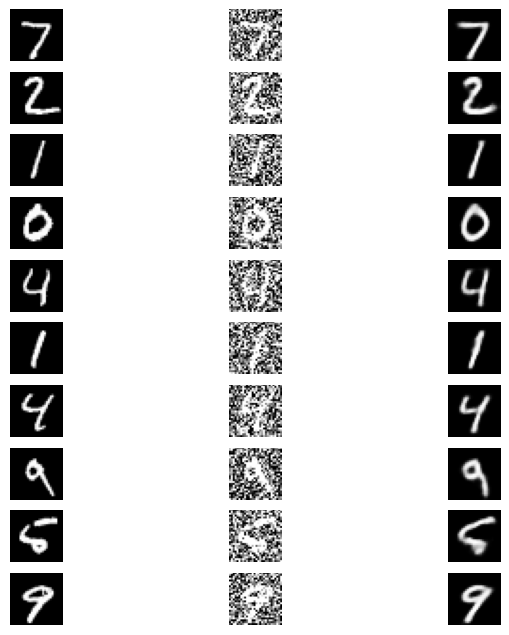

In [41]:
c = 1
fig = plt.figure(figsize=(8, 8))

with torch.no_grad():
    output = denoiser(next(iter(test_noisy_loader)))

for i in range(10):  # This only plots the first 10 images
    for j in range(3):
        if j == 0:
            img = tensor_x_test[i,0].cpu().numpy()
        elif j == 1:
            img = tensor_x_test_noisy[i,0].cpu().numpy()
        elif j == 2:
            img = output[i,0].cpu().numpy()       # denoised image
        else:
            pass

        fig.add_subplot(10, 3, c)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        c += 1

print("  Real              Noisy              Denoised")
plt.show()

We observe that the outputs are very close to the original images, even for test set images that the model has never seen before. The result is impressive! The noise has been completely removed, even though it was very strong. This is much better than the non-AI techniques used in previous labs (Gaussian blur, median filter, non-local means, etc.). However, some small details have been removed, such as an artifact on the 9 and on the 6, but overall the contours are perfectly preserved.

### Q11: Modify the AutoEncoder into a Variational AutoEncoder (VAE)

In this exercise, you will modify the previous AutoEncoder architecture to build a **Variational AutoEncoder (VAE)** in **PyTorch**, to learn a gaussian distrbution latent space.

A VAE differs from a standard AutoEncoder because the encoder does not directly output a single latent vector.  
Instead, it learns the parameters of a probability distribution in the latent space.

More precisely, the encoder must produce:

- **`mu`**: the mean vector of the latent distribution
- **`logvar`**: the logarithm of the variance vector

Then, instead of directly using a deterministic latent vector, we sample a latent variable using the **reparameterization trick**.


#### Step 1: Modify the encoder output

Modify the encoder so that, after the flattening step, it does not produce a single latent vector anymore.

Instead, create **two fully connected layers** using `torch.nn.Linear`:

- one layer to compute **`mu`**
- one layer to compute **`logvar`**

Both outputs must have size `latent_dim`.


#### Step 2: Compute the standard deviation

From `logvar`, compute the standard deviation `sigma` using:

`sigma` = torch.exp(0.5 * logvar)

In general to build the gaussian distribution for a standard VAE we apply the formula: latent= mu + eps * sigma, where eps follow a gaussian a standard gaussian distribution.

#### Step 3: Train the VAE 
- Train the VAE model for 30 epochs as  for AE model






In [23]:
class EncoderVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels = 1, out_channels = 16, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, stride = 2, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU()
        )
       
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64*7*7,latent_dim)
        self.fc2 = nn.Linear(64*7*7, latent_dim)        

        self.enc_shape = None

    def forward(self, x):
        x = self.features(x)
        self.enc_shape = x.shape
        x = self.flatten(x)
        mu = self.fc1(x)
        logvar = self.fc2(x)
        sigma = torch.exp(0.5*logvar)
        eps = torch.randn_like(sigma)
        latent = mu + eps * sigma
        return mu, logvar, latent

In [24]:
# Full VAE
#TODO
class VariationalAutoEncoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = EncoderVAE(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, logvar, latent_space = self.encoder(x)
        denoise_out = self.decoder(latent_space)
        return denoise_out, mu, logvar


# VAE Loss
def vae_loss(recon_x, x, mu, logvar):
    reconstruction_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - torch.exp(logvar))
    return reconstruction_loss + kl_loss


# Model, criterion, optimizer
latent_dim = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vae = VariationalAutoEncoder(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

print(vae)

VariationalAutoEncoder(
  (encoder): EncoderVAE(
    (features): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
    )
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc1): Linear(in_features=3136, out_features=16, bias=True)
    (fc2): Linear(in_features=3136, out_features=16, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=16, out_features=3136, bias=True)
    (features): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

In [28]:
# Training Final AutoEncoder
batch_size = 500
epochs = 30

tensor_x_train_noisy = torch.from_numpy(x_train_noisy).float().unsqueeze(1).to(device)
tensor_x_test_noisy = torch.from_numpy(x_test_noisy).float().unsqueeze(1).to(device)
train_noisy_loader = DataLoader(tensor_x_train_noisy, batch_size = batch_size, shuffle = False)
train_loader = DataLoader(tensor_x_train, batch_size = batch_size, shuffle = False)


vae.train()
for epoch in range(epochs):
    epoch_train_loss = 0
    for batch_noisy, batch_normal in zip(train_noisy_loader, train_loader):
        output, mu, logvar = vae(batch_noisy)
        loss = vae_loss(output, batch_normal, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() / len(train_loader)
        
        

    print(f"Epoch [{epoch+1}/{epochs}] - train_loss: {epoch_train_loss:.6f}")

        
        

Epoch [1/30] - train_loss: 23631.589795
Epoch [2/30] - train_loss: 20519.055208
Epoch [3/30] - train_loss: 18963.635107
Epoch [4/30] - train_loss: 18318.768099
Epoch [5/30] - train_loss: 17916.282601
Epoch [6/30] - train_loss: 17632.571924
Epoch [7/30] - train_loss: 17466.971338
Epoch [8/30] - train_loss: 17285.734554
Epoch [9/30] - train_loss: 17167.674585
Epoch [10/30] - train_loss: 17060.643595
Epoch [11/30] - train_loss: 16939.194019
Epoch [12/30] - train_loss: 16859.827702
Epoch [13/30] - train_loss: 16761.702148
Epoch [14/30] - train_loss: 16683.520492
Epoch [15/30] - train_loss: 16603.914355
Epoch [16/30] - train_loss: 16538.298258
Epoch [17/30] - train_loss: 16473.898177
Epoch [18/30] - train_loss: 16422.951115
Epoch [19/30] - train_loss: 16389.249520
Epoch [20/30] - train_loss: 16354.394718
Epoch [21/30] - train_loss: 16317.951497
Epoch [22/30] - train_loss: 16266.854972
Epoch [23/30] - train_loss: 16242.474194
Epoch [24/30] - train_loss: 16229.241659
Epoch [25/30] - train_los

Q13: Test the model on the test set as previously. Plot a samples of images.

In [29]:
# Retrieving model predictions for the test data
tensor_x_test_noisy = torch.from_numpy(x_test_noisy).float().unsqueeze(1).to(device)
test_noisy_loader = DataLoader(tensor_x_test_noisy, batch_size = batch_size, shuffle = False)
image_loader_in_order = DataLoader(tensor_x_test, batch_size = batch_size, shuffle = False)

vae.eval()

with torch.no_grad():

    test_noisy_loss = 0
    
    for batch_noisy, batch_normal in zip(test_noisy_loader, image_loader_in_order):
        output, mu, logvar = vae(batch_noisy)
        loss = vae_loss(output, batch_normal, mu, logvar)
        test_noisy_loss += loss.item()/len(test_noisy_loader)


print("erreur entre les images originales et les images débruitées :", test_noisy_loss)
        

erreur entre les images originales et les images débruitées : 15957.014404296873


The error on the test set is close to that on the training set. This suggests that the model is not overfitting.

  Real              Noisy              Denoised


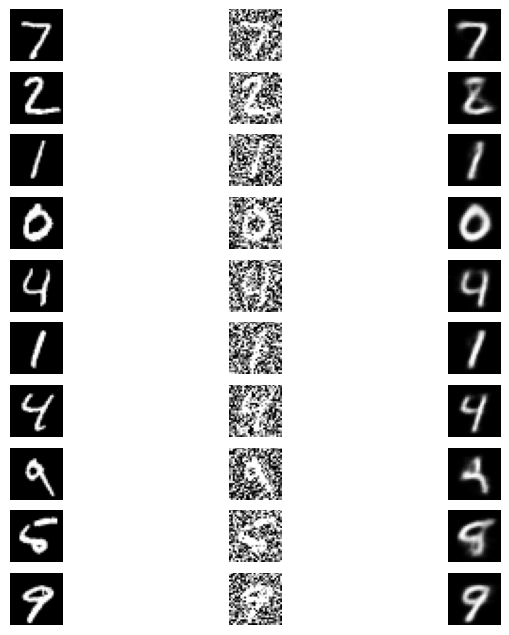

In [31]:
c = 1
fig = plt.figure(figsize=(8, 8))

with torch.no_grad():
    output, mu, logvar = vae(next(iter(test_noisy_loader)))

for i in range(10):  # This only plots the first 10 images
    for j in range(3):
        if j == 0:
            img = tensor_x_test[i,0].cpu().numpy()
        elif j == 1:
            img = tensor_x_test_noisy[i,0].cpu().numpy()
        elif j == 2:
            img = output[i,0].cpu().numpy()       # denoised image
        else:
            pass

        fig.add_subplot(10, 3, c)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        c += 1

print("  Real              Noisy              Denoised")
plt.show()

Similarly to the autoencoder, the result is very impressive: the noise has been completely removed. However, we observe that some images were poorly reconstructed; for example, a 2 was transformed into an 8. Also, we can see that the images are a bit blurry.

Q12: Compare the results provided by AE and VAE using PSNR and MSE. 

- Is there any difference between VAE and AE? 
- Does the VAE remove noise correctly?
- Are the reconstructed images sharper or blurrier than those produced by the standard AutoEncoder?
- What is the effect of modeling the latent space as a Gaussian distribution?
- In your opinion, which model is more suitable for image denoising?

In [44]:
import math
vae.eval()
denoiser.eval()

with torch.no_grad():

    MSE_AE = 0
    MSE_VAE = 0
    
    
    for batch_noisy, batch_normal in zip(test_noisy_loader, image_loader_in_order):
        output_AE = denoiser(batch_noisy)
        loss_AE = criterion(output_AE, batch_normal)
        
        output_VAE, mu, logvar = vae(batch_noisy)
        loss_VAE = criterion(output_VAE, batch_normal)
        
        MSE_AE += loss_AE.item() / len(test_noisy_loader)
        MSE_VAE += loss_VAE.item() / len(test_noisy_loader)

    PSNR_AE = 10*math.log10(1/MSE_AE)
    PSNR_VAE = 10*math.log10(1/MSE_VAE)

print("average MSE of the AE on test set : ", MSE_AE, "PSNR corresponding : ", PSNR_AE)
print("average MSE of the VAE on test set : ", MSE_VAE, "PSNR corresponding : ", PSNR_VAE)

average MSE of the AE on test set :  0.016224670875817533 PSNR corresponding :  17.8982410428205
average MSE of the VAE on test set :  0.027072099316865206 PSNR corresponding :  15.674780653828185


Is there any difference between VAE and AE?
Yes there are some differences between the results provided by AE and VAE, as explain the next answers.

Does the VAE remove noise correctly?
Partially. it reduces noise but also removes details, and sometimes adds some elements. For example the "2" becomes an "8". 

Are the reconstructed images sharper or blurrier?
VAE images are blurrier than AE outputs.

Effect of Gaussian latent space?
Gaussian latent space creates a smooth, continuous latent space. It makes the reconstructed images a bit blurrier. Sometimes some elements not present initially are present on the reconstructed image. Perharps it could enable image generation.

Which model is more suitable for denoising?
Visually, it seems like the AE is more precise at denoising images. We can also see this in the metrics : the MSE is higher for the VAE than for the AE, and the PSNR is Higher for the AE than for the VAE. 
To summarize, AE focuses directly on minimizing reconstruction error and can learn to remove noise while preserving important details. The VAE, which could be useful for generative tasks, tends to oversmooth the image and is so less effective for precise denoising.
To conclude, for a denoising task, AE is more suitable. 